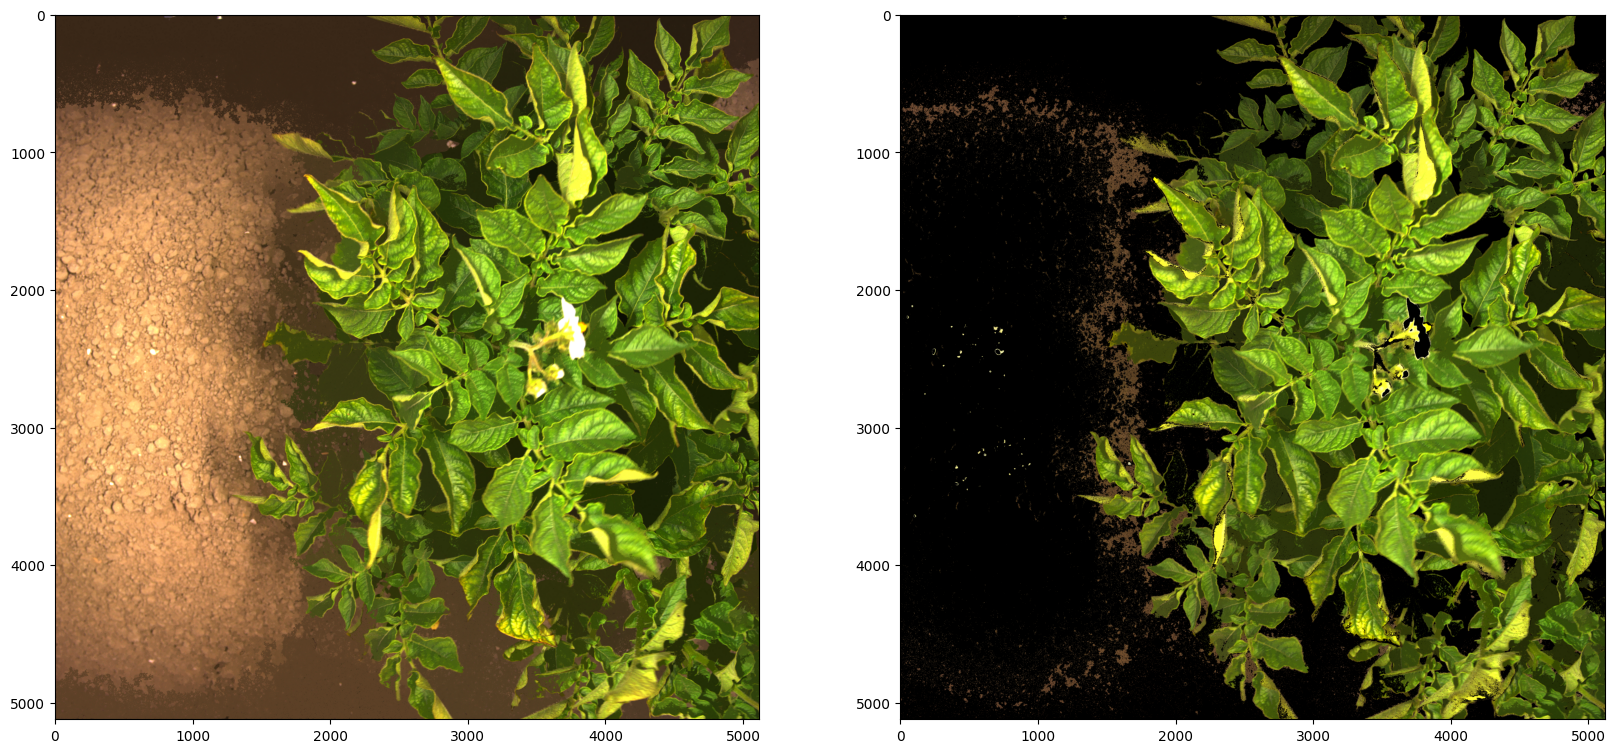

In [6]:
import skimage.io
import matplotlib.pyplot as plt
import numpy as np
import torch
from gmlvq import gmlvq
import pixel_classification_train as helper

# img = skimage.io.imread("uh-lettuce.png")
# img = skimage.io.imread("../../output/normalized_16bpc.png")
img = skimage.io.imread("../../output/output.png")
# img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Bladrol/74b3113b-ba8d-4f84-ab1a-93865f0a9b1c.png")

lvq = gmlvq()
lvq.load('pix-classifier-2025-07-03-leaves.pt')    

feats = torch.from_numpy(helper.rgb_uint8_to_feats(img))

with torch.no_grad():
    dist = lvq.net.proto_distances(feats).detach().numpy()

scalar = dist[:, 0] - dist[:, 1]
scalar = scalar.reshape(img.shape[0:2])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20,20))
ax0.imshow(img)
img[scalar < 0.0, :] = 0
ax1.imshow(img)